In [16]:
!pip install ultralytics -q

In [17]:
!pip install torch torchvision Pillow -q

In [18]:
import torch
from PIL import Image

In [19]:
import cv2
import os
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from collections import defaultdict
from PIL import Image
import zipfile
import shutil

In [20]:
# Удалить старые предсказания
if os.path.exists('runs/detect/predict'):
    shutil.rmtree('runs/detect/predict')

In [21]:
from ultralytics import YOLO

In [22]:
model_path = '/kaggle/input/models/mashamalyshkina/lenta-yolo-model/pytorch/default/1/lenta_yolo_model.pt'

In [23]:
model = YOLO(model_path)

In [24]:
# Функция для отрисовки тренировочных данных
def demonstrate_train_data(
    image_path: str,
    label_path: str
    ) -> Figure:

    # Загрузка изображения
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Конвертация в RGB для matplotlib
    h, w = image.shape[:2]

    # Чтение меток
    with open(label_path, 'r') as f:
        labels = f.readlines()

    # Отрисовка bounding boxes
    for label in labels:
        class_id, x_center, y_center, width, height = map(float, label.split())
        class_id = int(class_id)

        # Конвертация из YOLO-формата (нормированные координаты) в пиксели
        x_center *= w
        y_center *= h
        width *= w
        height *= h
        x1 = int(x_center - width/2)
        y1 = int(y_center - height/2)
        x2 = int(x_center + width/2)
        y2 = int(y_center + height/2)

        # Рисуем прямоугольник и подпись
        cv2.rectangle(image, (x1, y1), (x2, y2), colors[class_id], 10)
        cv2.putText(image, classes[class_id], (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 2, colors[class_id], 2)

    # Вывод изображения
    fig = plt.figure(figsize=(14,10))
    array = np.array(image)
    plt.imshow(array, cmap='gray')
    plt.colorbar()
    plt.axis('off')
    plt.close(fig)

    return fig

In [25]:
classes = ['price_tag']
colors = [(255,0,0)]

In [26]:
input_path = '/kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.03.519.jpg'

In [27]:
results = model.predict(
    source=input_path,
    conf=0.1,
    save=True,
    save_txt=True,
    # save_conf=False
)


image 1/1 /kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.03.519.jpg: 640x384 13 price tags, 72.5ms
Speed: 2.4ms preprocess, 72.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /kaggle/working/runs/detect/predict
1 label saved to /kaggle/working/runs/detect/predict/labels


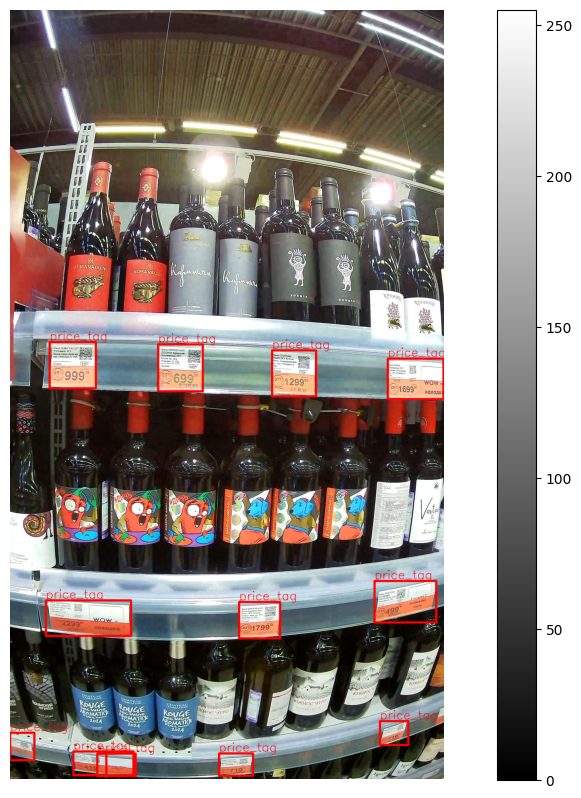

In [28]:
image_path = input_path
label_path = '/kaggle/working/runs/detect/predict/labels/26_2-10.mp4_snapshot_00.03.519.txt'

demonstrate_train_data(image_path, label_path)


image 1/1 /kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.12.195.jpg: 640x384 12 price tags, 65.0ms
Speed: 1.9ms preprocess, 65.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /kaggle/working/runs/detect/predict
1 label saved to /kaggle/working/runs/detect/predict/labels


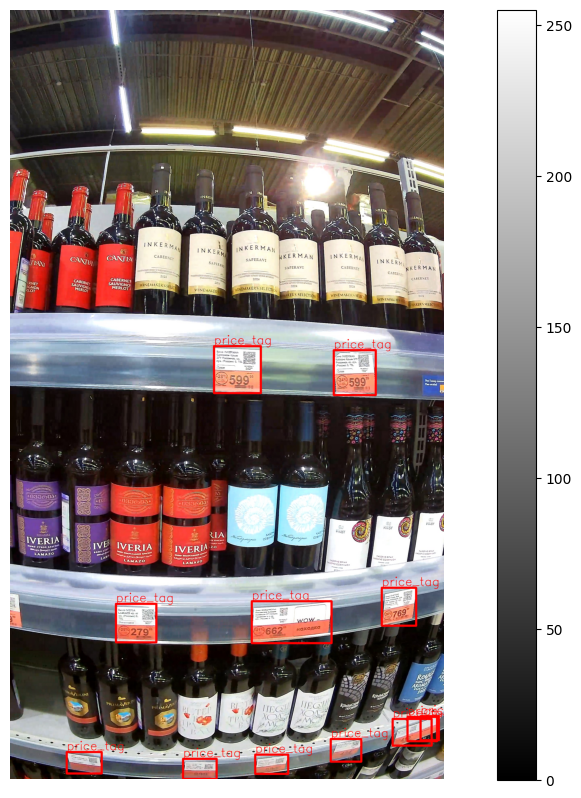

In [32]:
if os.path.exists('runs/detect/predict'):
    shutil.rmtree('runs/detect/predict')
    
input_path = '/kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.12.195.jpg'
results = model.predict(
    source=input_path,
    conf=0.1,
    save=True,
    save_txt=True
)

label_path = '/kaggle/working/runs/detect/predict/labels/26_2-10.mp4_snapshot_00.12.195.txt'
demonstrate_train_data(input_path, label_path)


image 1/1 /kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.20.558.jpg: 640x384 9 price tags, 62.8ms
Speed: 2.3ms preprocess, 62.8ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /kaggle/working/runs/detect/predict
1 label saved to /kaggle/working/runs/detect/predict/labels


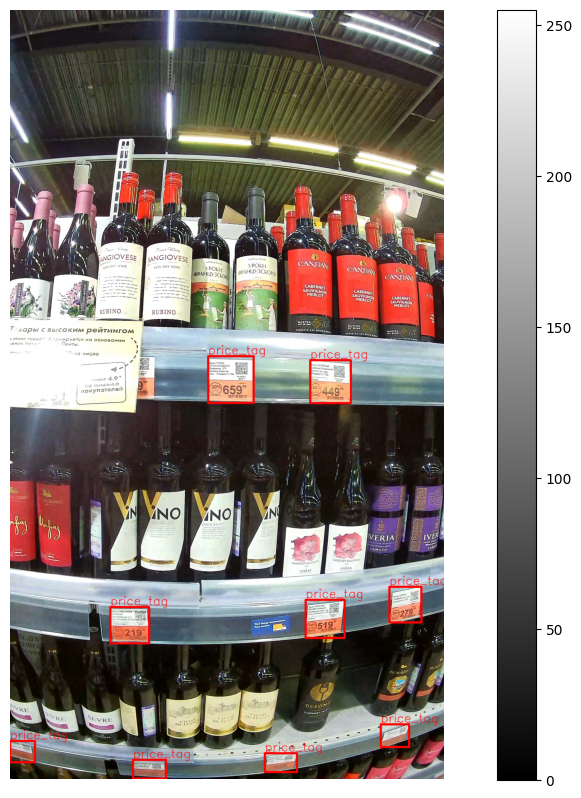

In [33]:
if os.path.exists('runs/detect/predict'):
    shutil.rmtree('runs/detect/predict')
    
input_path = '/kaggle/input/datasets/mashamalyshkina/test-images/26_2-10.mp4_snapshot_00.20.558.jpg'
results = model.predict(
    source=input_path,
    conf=0.1,
    save=True,
    save_txt=True
)

label_path = '/kaggle/working/runs/detect/predict/labels/26_2-10.mp4_snapshot_00.20.558.txt'
demonstrate_train_data(input_path, label_path)